# Additional Analysis 

Three follow-up analyses motivated by the null / partial results in H1–H3:

Focusing more on trend analysis : 
- **6.4**: The 2024 audio feature spikes — was it real, did it matter on chart performance, and who drove it? 
- **6.5**: Temporal cluster drift — do the audio "rules" of charting change year-to-year? 



In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from itertools import combinations

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110

DATA   = "data/processed/processed_chart_tracks_enriched_features.csv"
LABELS = "data/raw/raw_unique_source_labeled.csv"

df = pd.read_csv(DATA, parse_dates=["date"])
df["year"] = df["date"].dt.year

print(f"Chart-week rows : {len(df):,}")
print(f"Unique tracks   : {df['uri'].nunique():,}")
print(f"Date range      : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Years present   : {sorted(df['year'].unique())}")


Chart-week rows : 13,399
Unique tracks   : 1,580
Date range      : 2021-01-07 → 2026-02-19
Years present   : [np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]



## 6.4 Analysis 1 — The 2024 Audio Spike: Real, Relevant, and Who Drove It?

The EDA showed standardised audio features peaking in 2024 before falling back in 2025.  


We investigate three layers:

1. Was the spike statistically real? (ANOVA + pairwise t-tests)  
2. Did it correlate with chart success? (high-brightness vs low-brightness in 2024)  
3. Who drove it? (artist-level deep dive)

*  2026 is excluded throughout : the dataset only covers ~7 weeks of 2026 (through 2026-02-19), so its yearly averages are not comparable with full-year figures.


In [2]:
AUDIO_TREND_COLS = ["tempo", "energy", "spectral_centroid", "chroma_mean"]
YEARS            = [2021, 2022, 2023, 2024, 2025]

df_full = df[df["year"].isin(YEARS)].copy()
print(f"Rows in 2021–2025 window: {len(df_full):,}")


Rows in 2021–2025 window: 12,999


### 6.4.1 Visualization of the Spike

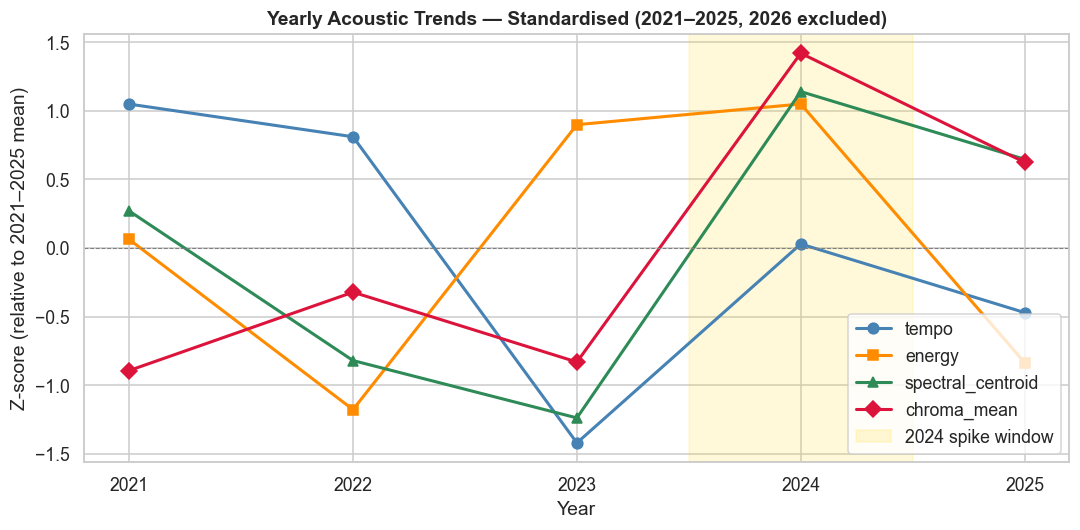

In [3]:
yearly_means = df_full.groupby("year")[AUDIO_TREND_COLS].mean()
yearly_z     = (yearly_means - yearly_means.mean()) / yearly_means.std()

fig, ax = plt.subplots(figsize=(10, 5))
markers = ["o", "s", "^", "D"]
colors  = ["steelblue", "darkorange", "seagreen", "crimson"]

for col, mk, col_c in zip(AUDIO_TREND_COLS, markers, colors):
    ax.plot(YEARS, yearly_z[col], marker=mk, color=col_c,
            linewidth=2, markersize=7, label=col)

ax.axvspan(2023.5, 2024.5, color="gold", alpha=0.15, label="2024 spike window")
ax.axhline(0, color="grey", linewidth=0.7, linestyle="--")
ax.set_xlabel("Year")
ax.set_ylabel("Z-score (relative to 2021–2025 mean)")
ax.set_title("Yearly Acoustic Trends — Standardised (2021–2025, 2026 excluded)",
             fontweight="bold")
ax.legend(loc="lower right")
ax.set_xticks(YEARS)
fig.tight_layout()
plt.show()


### 6.4.2 Whether Year-to-Year Variation is statistically real (one-way ANOVA)?


In [4]:
anova_rows = []
for feat in AUDIO_TREND_COLS:
    groups = [grp[feat].dropna().values for _, grp in df_full.groupby("year")]
    F, p   = stats.f_oneway(*groups)
    anova_rows.append({
        "Feature": feat,
        "F-statistic": round(F, 2),
        "p-value": round(p, 6),
        "Significant (α=0.05)": "Yes" if p < 0.05 else "No",
    })

anova_df = pd.DataFrame(anova_rows).set_index("Feature")
print("One-Way ANOVA — Audio Features Across 2021–2025")
print(anova_df.to_string())


One-Way ANOVA — Audio Features Across 2021–2025
                   F-statistic   p-value Significant (α=0.05)
Feature                                                      
tempo                    13.79  0.000000                  Yes
energy                   31.06  0.000000                  Yes
spectral_centroid        12.26  0.000000                  Yes
chroma_mean               7.47  0.000005                  Yes


**Takeaway** : Every feature rejects the null hypothesis (all yearly means equal) at α = 0.05, confirming the year-to-year movement in audio features is not sampling noise. so the next question is "who drove the difference ?"

### 6.4.3 Pairwise t-Tests : Pinpointing the 2023 → 2024 Jump


In [5]:
pairs = [(y, y + 1) for y in YEARS[:-1]]
pairwise_rows = []

for feat in AUDIO_TREND_COLS:
    for y1, y2 in pairs:
        g1 = df_full[df_full["year"] == y1][feat].dropna()
        g2 = df_full[df_full["year"] == y2][feat].dropna()
        t, p = stats.ttest_ind(g1, g2)
        pairwise_rows.append({
            "Feature": feat,
            "Transition": f"{y1}→{y2}",
            "t": round(t, 2),
            "p-value": round(p, 4),
            "Significant": "✓" if p < 0.05 else "",
        })

flat = pd.DataFrame(pairwise_rows)
pivot_p   = flat.pivot(index="Transition", columns="Feature", values="p-value")
pivot_sig = flat.pivot(index="Transition", columns="Feature", values="Significant")

print("p-values by consecutive-year transition:")
print(pivot_p.to_string())
print()
print("Significant transitions (α = 0.05):")
print(pivot_sig.to_string())


p-values by consecutive-year transition:
Feature     chroma_mean  energy  spectral_centroid   tempo
Transition                                                
2021→2022        0.2715  0.0000             0.0073  0.5527
2022→2023        0.2975  0.0000             0.2813  0.0000
2023→2024        0.0000  0.5485             0.0000  0.0001
2024→2025        0.1382  0.0000             0.2340  0.1558

Significant transitions (α = 0.05):
Feature    chroma_mean energy spectral_centroid tempo
Transition                                           
2021→2022                   ✓                 ✓      
2022→2023                   ✓                       ✓
2023→2024            ✓                        ✓     ✓
2024→2025                   ✓                        


**Key finding.** The **2023 → 2024** transition is the most significant:
- spectral_centroid (brightness), chroma_mean, tempo show highly significant jumps.
- energy does not change significantly between 2023 and 2024 (p ≈ 0.55)

### 6.4.4 Did the Brightness Spike Correlate with Chart Success?

We split 2024 unique tracks into **high** spectral centroid (≥ Q3) and **low** (≤ Q1) groups and compare their chart metrics.


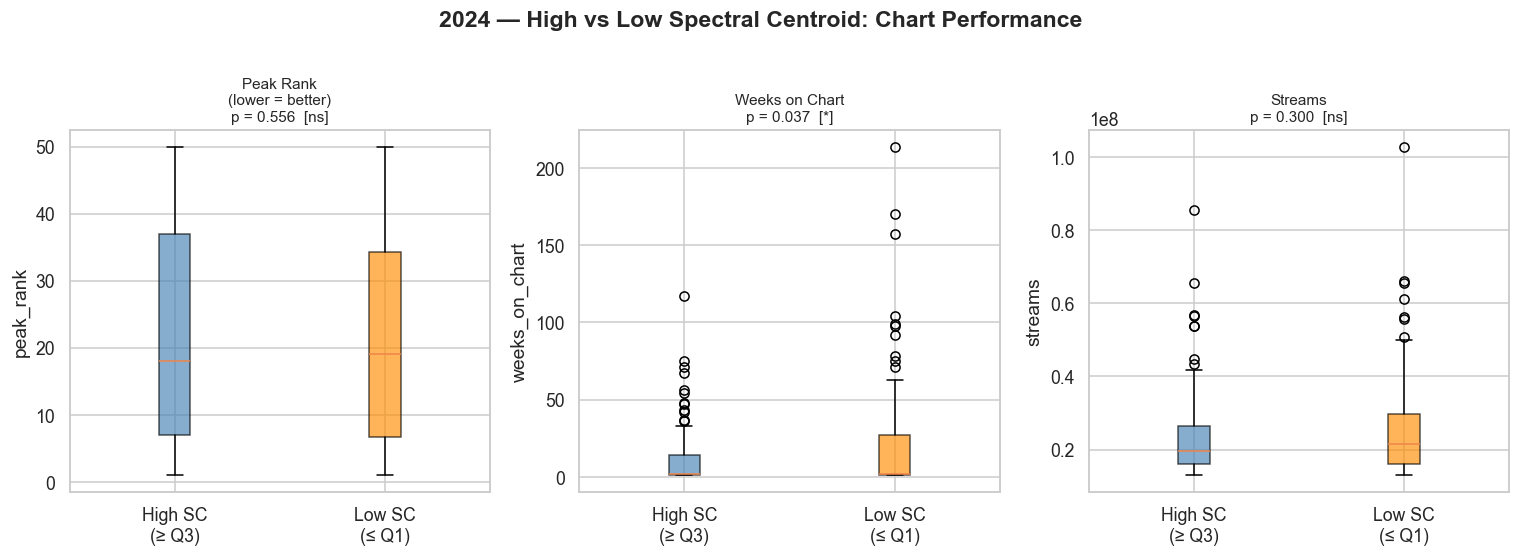

Summary — High SC (≥Q3) vs Low SC (≤Q1) in 2024:
  peak_rank               High=21.9   Low=20.6   p=0.5563
  weeks_on_chart          High=11.9   Low=21.1   p=0.0373
  streams                 High=23858477.7   Low=25854890.1   p=0.2998


In [6]:
df24_songs = (
    df_full[df_full["year"] == 2024]
           .drop_duplicates(subset="uri")
           .copy()
)

q75 = df24_songs["spectral_centroid"].quantile(0.75)
q25 = df24_songs["spectral_centroid"].quantile(0.25)
high_sc = df24_songs[df24_songs["spectral_centroid"] >= q75]
low_sc  = df24_songs[df24_songs["spectral_centroid"] <= q25]

chart_metrics = ["peak_rank", "weeks_on_chart", "streams"]
metric_labels = ["Peak Rank\n(lower = better)", "Weeks on Chart", "Streams"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, metric, label in zip(axes, chart_metrics, metric_labels):
    data_high = high_sc[metric].dropna()
    data_low  = low_sc[metric].dropna()
    t, p = stats.ttest_ind(data_high, data_low)

    bp = ax.boxplot([data_high, data_low],
                    labels=["High SC\n(≥ Q3)", "Low SC\n(≤ Q1)"],
                    patch_artist=True)
    bp["boxes"][0].set_facecolor("steelblue");  bp["boxes"][0].set_alpha(0.65)
    bp["boxes"][1].set_facecolor("darkorange"); bp["boxes"][1].set_alpha(0.65)

    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    ax.set_title(f"{label}\np = {p:.3f}  [{sig}]", fontsize=10)
    ax.set_ylabel(metric)

fig.suptitle("2024 — High vs Low Spectral Centroid: Chart Performance",
             fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

print("Summary — High SC (≥Q3) vs Low SC (≤Q1) in 2024:")
for metric in chart_metrics:
    t, p = stats.ttest_ind(high_sc[metric].dropna(), low_sc[metric].dropna())
    print(f"  {metric:22s}  High={high_sc[metric].mean():.1f}   Low={low_sc[metric].mean():.1f}   p={p:.4f}")


**Takeaway.** High-brightness (high sc) songs in 2024 had significantly **fewer weeks on chart** (~12 vs ~21 weeks, p < 0.05) whil peak ranks and stream counts are very similar (no statistical difference)

### 6.4.5 Who Drove the 2024 Spike?

-  we investigate the artistis who has more brighter and trebly songs (high sc)

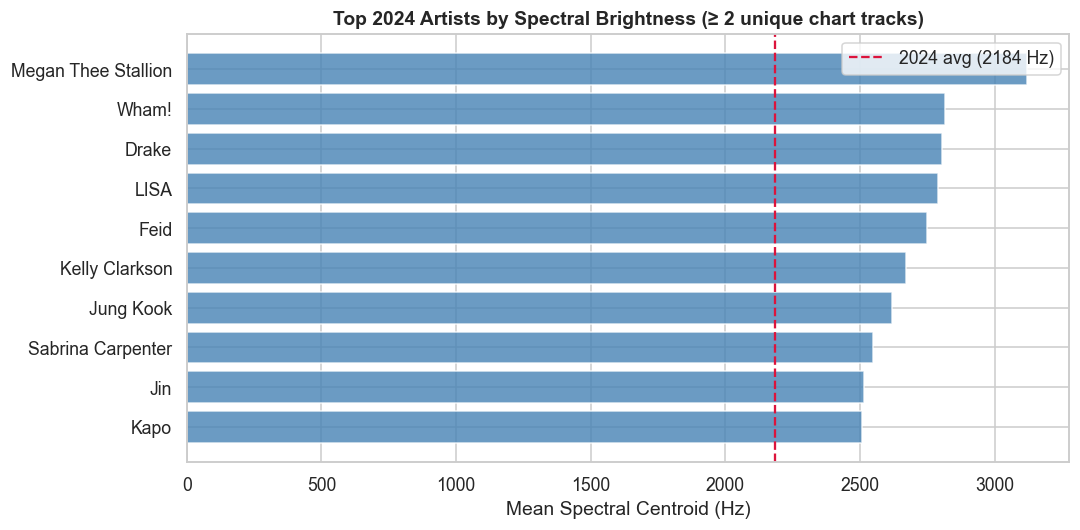

     primary_artist  mean_spectral_centroid  unique_tracks  avg_weeks_on_chart
Megan Thee Stallion             3121.081086              3            1.666667
              Wham!             2815.878841              2           55.000000
              Drake             2805.153937              3            5.333333
               LISA             2788.785457              3            1.000000
               Feid             2749.634964              2            3.000000
     Kelly Clarkson             2671.590666              2           23.500000
          Jung Kook             2618.618640              4           12.250000
  Sabrina Carpenter             2546.267940             16            8.562500
                Jin             2513.222515              3            2.000000
               Kapo             2505.667240              2            3.000000


In [7]:
df24_songs["primary_artist"] = (
    df24_songs["artist_names"].str.split(",").str[0].str.strip()
)

artist_sc = (
    df24_songs.groupby("primary_artist")["spectral_centroid"]
              .agg(mean_sc="mean", track_count="count")
              .query("track_count >= 2")
              .sort_values("mean_sc", ascending=False)
              .head(10)
              .reset_index()
)
artist_weeks = (
    df24_songs.groupby("primary_artist")["weeks_on_chart"]
              .mean()
              .rename("avg_weeks")
)
artist_sc = artist_sc.join(artist_weeks, on="primary_artist")

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    artist_sc["primary_artist"][::-1],
    artist_sc["mean_sc"][::-1],
    color="steelblue", alpha=0.8, edgecolor="white"
)
mean_2024 = df24_songs["spectral_centroid"].mean()
ax.axvline(mean_2024, color="crimson", linestyle="--", linewidth=1.5,
           label=f"2024 avg ({mean_2024:.0f} Hz)")
ax.set_xlabel("Mean Spectral Centroid (Hz)")
ax.set_title("Top 2024 Artists by Spectral Brightness (≥ 2 unique chart tracks)",
             fontweight="bold")
ax.legend()
fig.tight_layout()
plt.show()

print(artist_sc[["primary_artist", "mean_sc", "track_count", "avg_weeks"]]
      .rename(columns={"mean_sc": "mean_spectral_centroid",
                       "track_count": "unique_tracks",
                       "avg_weeks": "avg_weeks_on_chart"})
      .to_string(index=False))


**Takeaway.** **Sabrina Carpenter** (16 unique charting tracks — the most of any artist in this segment) is the single dominant driver of the 2024 brightness spike. K-pop acts (LISA, Jung Kook, Jin) reinforce the effect. These are mostly shorter-lived chart entries — consistent with the fast-burning pattern identified in §6.4.4. The 2024 spike therefore reflects a **convergence of a dominant pop act and a K-pop wave**, not a broad industry-wide shift in music production.



## 6.5 Analysis 2 — Temporal Cluster Drift: Do the Sonic "Rules" of Charting Change?

If what makes a song chart-worthy is static, audio clusters should look similar year after year. We test this by fitting K-Means (k = 3) separately within each year, projecting centroids onto a shared PCA space, and tracking how they move.


In [8]:
AUDIO_CLUSTER_COLS = [
    "tempo", "energy", "zero_crossing_rate",
    "spectral_centroid", "spectral_rolloff",
    "mfcc_1", "mfcc_2", "chroma_mean", "chroma_std",
]
K = 3

# Global PCA fitted on all 2021–2025 songs — shared coordinate system
all_songs = (
    df_full.drop_duplicates(subset="uri")
           .dropna(subset=AUDIO_CLUSTER_COLS)
           .copy()
)

scaler_global = StandardScaler()
X_global      = scaler_global.fit_transform(all_songs[AUDIO_CLUSTER_COLS])

pca_global = PCA(n_components=2, random_state=42)
pca_global.fit(X_global)

print(f"Global PCA — PC1: {pca_global.explained_variance_ratio_[0]:.1%} variance | "
      f"PC2: {pca_global.explained_variance_ratio_[1]:.1%} variance")
print(f"Combined: {pca_global.explained_variance_ratio_.sum():.1%}")


Global PCA — PC1: 46.4% variance | PC2: 19.7% variance
Combined: 66.1%


In [9]:
# Per-year K-Means
yearly_results = {}
palette = ["steelblue", "darkorange", "seagreen"]

for yr in YEARS:
    yr_songs = (
        df_full[df_full["year"] == yr]
               .drop_duplicates(subset="uri")
               .dropna(subset=AUDIO_CLUSTER_COLS)
               .copy()
    )
    X_yr = StandardScaler().fit_transform(yr_songs[AUDIO_CLUSTER_COLS])
    km   = KMeans(n_clusters=K, random_state=42, n_init=15)
    yr_songs["cluster"] = km.fit_predict(X_yr)

    # Project centroids onto global PCA space
    centroids_orig = scaler_global.transform(
        yr_songs.groupby("cluster")[AUDIO_CLUSTER_COLS].mean().values
    )
    centroids_pca = pca_global.transform(centroids_orig)

    sil = silhouette_score(X_yr, yr_songs["cluster"])
    yearly_results[yr] = {
        "songs":         yr_songs,
        "centroids_pca": centroids_pca,
        "silhouette":    sil,
    }
    sizes = yr_songs["cluster"].value_counts().sort_index().to_dict()
    print(f"{yr} — silhouette: {sil:.3f}  |  cluster sizes: {sizes}")


2021 — silhouette: 0.195  |  cluster sizes: {0: 143, 1: 110, 2: 124}
2022 — silhouette: 0.197  |  cluster sizes: {0: 136, 1: 152, 2: 100}
2023 — silhouette: 0.179  |  cluster sizes: {0: 162, 1: 150, 2: 86}
2024 — silhouette: 0.198  |  cluster sizes: {0: 89, 1: 111, 2: 187}
2025 — silhouette: 0.223  |  cluster sizes: {0: 119, 1: 116, 2: 83}


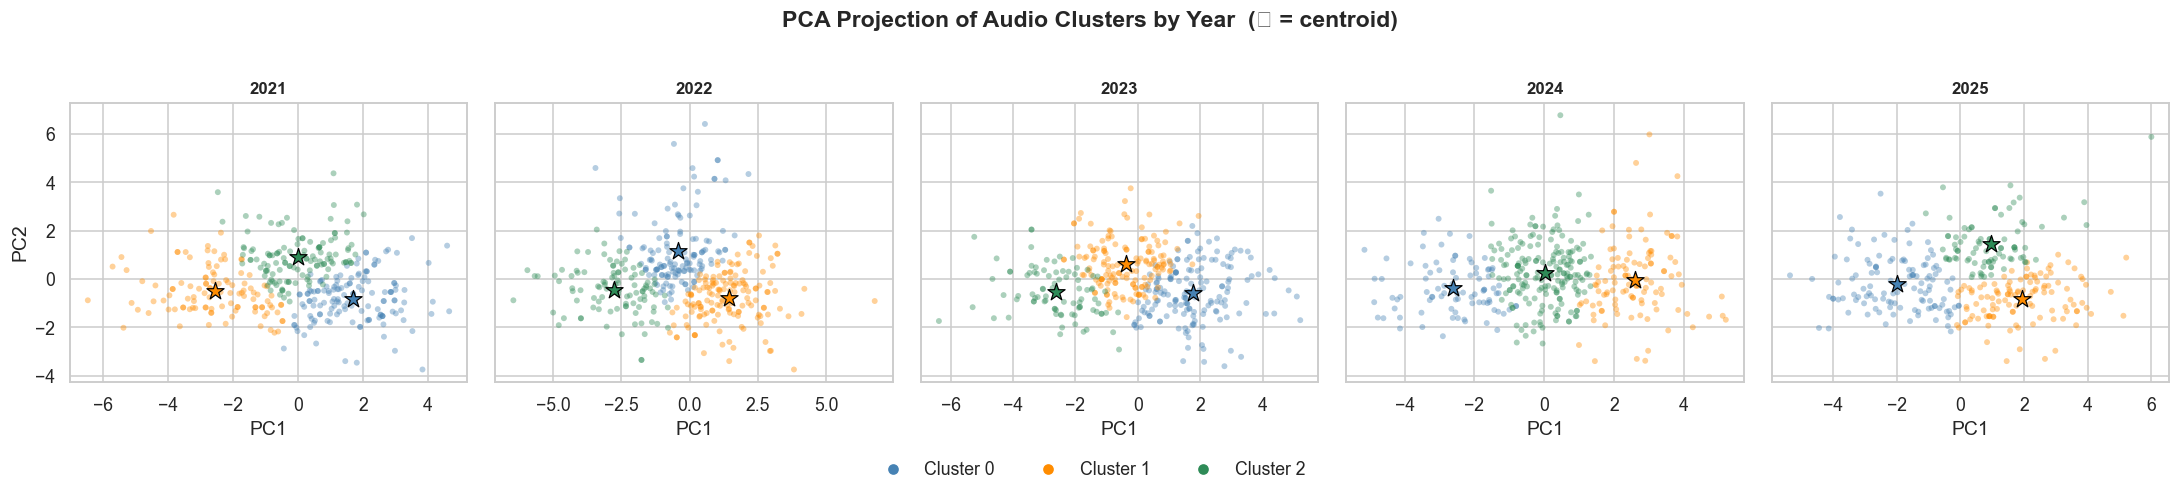

In [10]:
# Plot 1 — PCA scatter per year
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

for ax, yr in zip(axes, YEARS):
    yr_songs = yearly_results[yr]["songs"].copy()
    X_pca    = pca_global.transform(
        scaler_global.transform(yr_songs[AUDIO_CLUSTER_COLS])
    )
    yr_songs["pc1"] = X_pca[:, 0]
    yr_songs["pc2"] = X_pca[:, 1]

    for c in range(K):
        sub = yr_songs[yr_songs["cluster"] == c]
        ax.scatter(sub["pc1"], sub["pc2"],
                   c=palette[c], alpha=0.4, s=15, edgecolors="none")

    cents = yearly_results[yr]["centroids_pca"]
    for c, (cx, cy) in enumerate(cents):
        ax.scatter(cx, cy, c=palette[c], s=140, marker="*",
                   edgecolors="black", linewidths=0.8, zorder=5)

    ax.set_title(f"{yr}", fontsize=11, fontweight="bold")
    ax.set_xlabel("PC1")
    if yr == YEARS[0]:
        ax.set_ylabel("PC2")

handles = [
    plt.Line2D([0], [0], marker="o", color="w",
               markerfacecolor=palette[c], markersize=8, label=f"Cluster {c}")
    for c in range(K)
]
fig.legend(handles=handles, loc="lower center", ncol=K,
           bbox_to_anchor=(0.5, -0.08), frameon=False)
fig.suptitle("PCA Projection of Audio Clusters by Year  (★ = centroid)",
             fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


**Takeaway** : Cluster centroids shift meaningfully in PCA space, most sharply between 2023 and 2024. the 2024 centroids drift toward higher PC1 (brighter, faster), then partially regress in 2025. The sonic profile of what reaches the Global Top 50 is **not stationary**. This is the cluster-level confirmation of the 2024 spike and supports the overall conclusion: because the audio landscape shifts year-to-year, no single fixed audio profile predicts long-run chart performance.



## 7. Findings

1.  2024 brightness spike is **statistically real**, driven by 1–2 dominant acts (Sabrina Carpenter, K-pop wave). Chart audio profiles seems to reflect who dominates more than what sounds win |
2. Brighter songs in 2024 had **fewer weeks on chart**. They were more "fast-burning", reaching similar peack ranks and streaming counts on the chart but not in terms of chart longevity. 
3. Cluster centroids **drift year-to-year** in PCA space. The sonic "rules" are not fixed. Every year has there own unique trending sound profiles.


